Saved to Figures/gap_closure.png


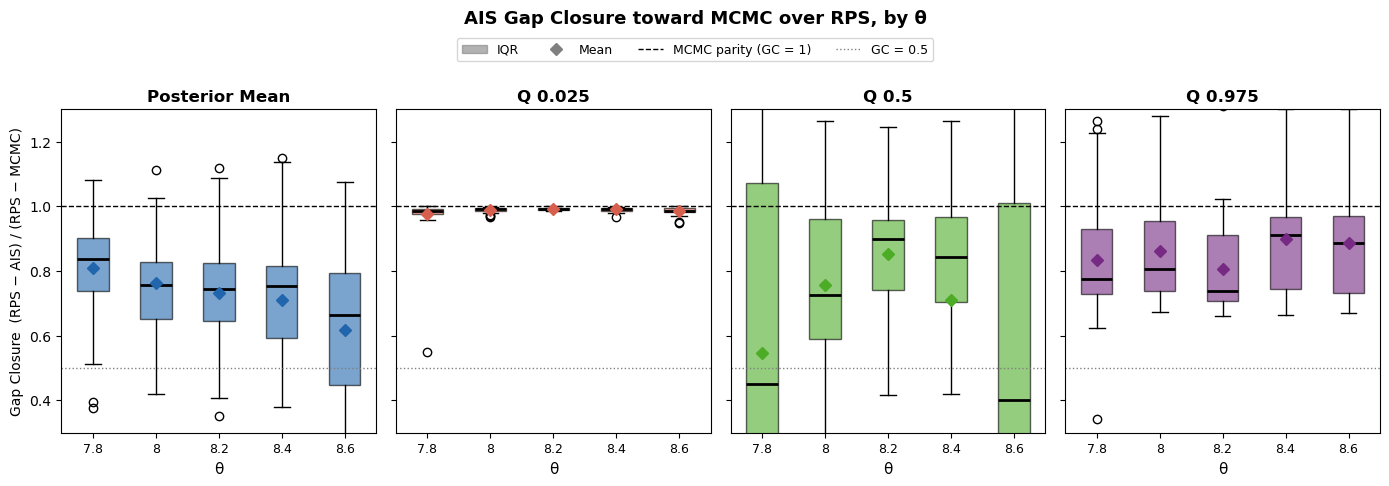

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
data=[]
for epoch in range(1,6):
    with open(f"./output1.2/sim1_result{epoch}.pkl", 'rb') as f:
        data.extend(pickle.load(f))

thetas = [7.8, 8, 8.2, 8.4, 8.6]
metrics = [
    ("Posterior Mean", None),
    ("Q 0.025",        "0.025"),
    ("Q 0.5",          "0.5"),
    ("Q 0.975",        "0.975"),
]


def get_errors(x, theta, q):
    if q is None:
        rps  = np.sum(np.abs(np.asarray(x[f"RPS_{theta}"]) - x["exact"]))
        ais  = np.sum(np.abs(np.asarray(x[f"AIS_{theta}"]) - x["exact"]))
        mcmc = np.sum(np.abs(x["MCMC"] - x["exact"]))
    else:
        rps  = np.sum(np.abs(x[f"RPS_{theta}_quantiles"][q]  - x["exact_quantiles"][q]))
        ais  = np.sum(np.abs(x[f"AIS_{theta}_quantiles"][q]  - x["exact_quantiles"][q]))
        mcmc = np.sum(np.abs(x["MCMC_quantiles"][q]          - x["exact_quantiles"][q]))
    return rps, ais, mcmc


colors = ["#2166ac", "#d6604d", "#4dac26", "#762a83"]
fig, axes = plt.subplots(1, 4, figsize=(14, 4.5), sharey=True)

for ax, (label, q), color in zip(axes, metrics, colors):
    gc_all = []
    for theta in thetas:
        gc = [(r - a) / (r - m)
              for x in data
              for r, a, m in [get_errors(x, theta, q)]]
        gc_all.append(gc)

    bp = ax.boxplot(gc_all, positions=range(len(thetas)), widths=0.5,
                    patch_artist=True, medianprops=dict(color="black", linewidth=2))
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    means = [np.mean(g) for g in gc_all]
    ax.plot(range(len(thetas)), means, "D", color=color, markersize=6, zorder=5)

    ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    ax.axhline(0.5, color="gray",  linestyle=":",  linewidth=1)

    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xticks(range(len(thetas)))
    ax.set_xticklabels([str(t) for t in thetas], fontsize=9)
    ax.set_xlabel("θ", fontsize=11)
    ax.set_ylim(0.3, 1.3)

axes[0].set_ylabel("Gap Closure  (RPS − AIS) / (RPS − MCMC)", fontsize=10)

legend_elements = [
    mpatches.Patch(color="gray", alpha=0.6, label="IQR"),
    plt.Line2D([0], [0], marker="D", color="gray", markersize=6,
               linestyle="None", label="Mean"),
    plt.Line2D([0], [0], color="black", linestyle="--", linewidth=1,
               label="MCMC parity (GC = 1)"),
    plt.Line2D([0], [0], color="gray",  linestyle=":",  linewidth=1,
               label="GC = 0.5"),
]
fig.legend(handles=legend_elements, loc="upper center", ncol=4,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, 1.02))

fig.suptitle("AIS Gap Closure toward MCMC over RPS, by θ", fontsize=13,
             fontweight="bold", y=1.07)
plt.tight_layout()
plt.savefig("../Figures/gap_closure.png", dpi=150, bbox_inches="tight")
print("Saved to Figures/gap_closure.png")


In [8]:
len(data)

50

Drawing the accuracy plots

In [14]:
import numpy as np
AIS = dict()
RPS = dict()
MCMC = []
for theta in [7.8,8,8.2,8.4,8.6]:
    AIS[f"{theta}"] = []
    RPS[f"{theta}"] = []
for i in range(len(data)):
    x = data[i]
    MCMC.append(np.sum(np.abs(x["MCMC"]-x["exact"])))
    for theta in [7.8,8,8.2,8.4,8.6]:        
        RPS_diff = np.sum(np.abs(np.asarray(x[f"RPS_{theta}"])-x["exact"]))
        RPS[f"{theta}"].append(RPS_diff)

        AIS_diff = np.sum(np.abs(np.asarray(x[f"AIS_{theta}"])-x["exact"]))
        AIS[f"{theta}"].append(AIS_diff)


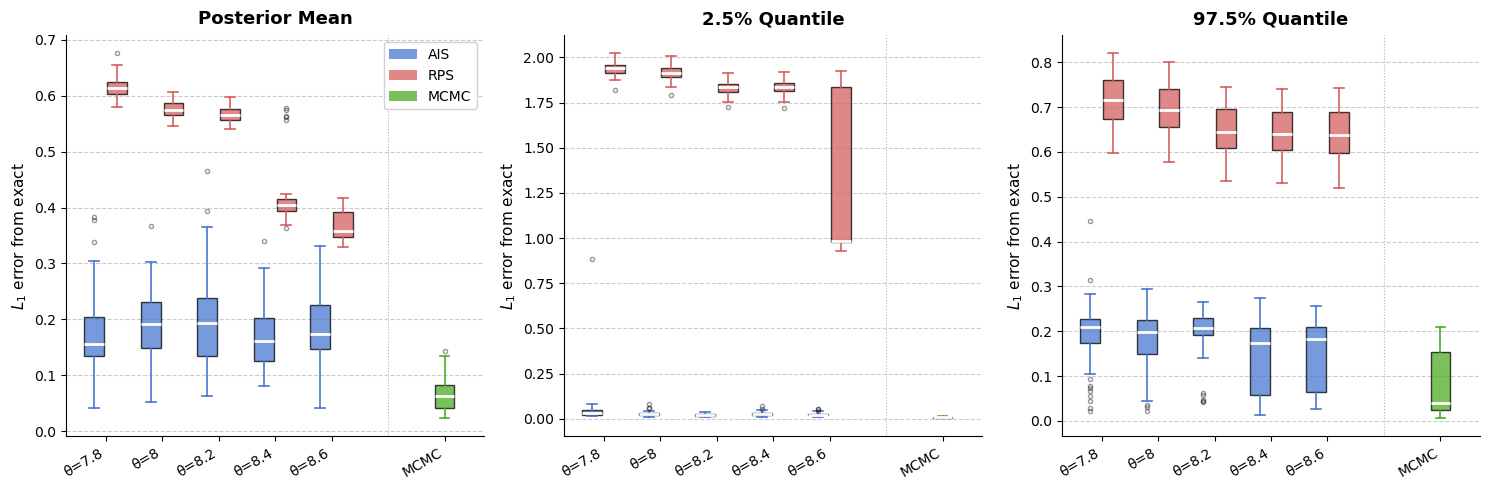

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Save posterior mean data (computed in previous cell)
AIS_mean = {k: list(v) for k, v in AIS.items()}
RPS_mean = {k: list(v) for k, v in RPS.items()}
MCMC_mean = list(MCMC)

# Compute 2.5% quantile errors
AIS_q025 = {f"{t}": [] for t in [7.8, 8, 8.2, 8.4, 8.6]}
RPS_q025 = {f"{t}": [] for t in [7.8, 8, 8.2, 8.4, 8.6]}
MCMC_q025 = []
for x in data:
    MCMC_q025.append(np.sum(np.abs(x["MCMC_quantiles"]["0.025"] - x["exact_quantiles"]["0.025"])))
    for theta in [7.8, 8, 8.2, 8.4, 8.6]:
        AIS_q025[f"{theta}"].append(np.sum(np.abs(x[f"AIS_{theta}_quantiles"]["0.025"] - x["exact_quantiles"]["0.025"])))
        RPS_q025[f"{theta}"].append(np.sum(np.abs(x[f"RPS_{theta}_quantiles"]["0.025"] - x["exact_quantiles"]["0.025"])))

# Compute 97.5% quantile errors
AIS_q975 = {f"{t}": [] for t in [7.8, 8, 8.2, 8.4, 8.6]}
RPS_q975 = {f"{t}": [] for t in [7.8, 8, 8.2, 8.4, 8.6]}
MCMC_q975 = []
for x in data:
    MCMC_q975.append(np.sum(np.abs(x["MCMC_quantiles"]["0.975"] - x["exact_quantiles"]["0.975"])))
    for theta in [7.8, 8, 8.2, 8.4, 8.6]:
        AIS_q975[f"{theta}"].append(np.sum(np.abs(x[f"AIS_{theta}_quantiles"]["0.975"] - x["exact_quantiles"]["0.975"])))
        RPS_q975[f"{theta}"].append(np.sum(np.abs(x[f"RPS_{theta}_quantiles"]["0.975"] - x["exact_quantiles"]["0.975"])))

# Build DataFrames (theta columns only; MCMC kept separate)
thetas = [7.8, 8, 8.2, 8.4, 8.6]
theta_labels = [f"θ={t}" for t in thetas]

def to_df(d):
    df = pd.DataFrame.from_dict(d)
    df.columns = theta_labels
    return df

AIS_mean_df = to_df(AIS_mean)
RPS_mean_df = to_df(RPS_mean)
AIS_q025_df = to_df(AIS_q025)
RPS_q025_df = to_df(RPS_q025)
AIS_q975_df = to_df(AIS_q975)
RPS_q975_df = to_df(RPS_q975)

# 3-panel figure: Posterior Mean | 2.5% Quantile | 97.5% Quantile
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
panel_titles = ["Posterior Mean", "2.5% Quantile", "97.5% Quantile"]
ais_dfs   = [AIS_mean_df, AIS_q025_df, AIS_q975_df]
rps_dfs   = [RPS_mean_df, RPS_q025_df, RPS_q975_df]
mcmc_data = [MCMC_mean,   MCMC_q025,   MCMC_q975]

n = len(thetas)
pos_ais  = np.arange(1, n + 1) - 0.2
pos_rps  = np.arange(1, n + 1) + 0.2
pos_mcmc = [n + 2]   # gap of 1 after the theta groups
w = 0.35

ais_color  = "#4878CF"
rps_color  = "#D65F5F"
mcmc_color = "#4DAC26"

bp_kw = dict(patch_artist=True, medianprops=dict(color="white", linewidth=2))

for ax, title, ais_df, rps_df, mcmc_vals in zip(axes, panel_titles, ais_dfs, rps_dfs, mcmc_data):
    ax.boxplot(
        ais_df.values, positions=pos_ais, widths=w, **bp_kw,
        boxprops=dict(facecolor=ais_color, alpha=0.75),
        whiskerprops=dict(color=ais_color, linewidth=1.2),
        capprops=dict(color=ais_color, linewidth=1.2),
        flierprops=dict(marker="o", color=ais_color, alpha=0.4, markersize=3),
    )
    ax.boxplot(
        rps_df.values, positions=pos_rps, widths=w, **bp_kw,
        boxprops=dict(facecolor=rps_color, alpha=0.75),
        whiskerprops=dict(color=rps_color, linewidth=1.2),
        capprops=dict(color=rps_color, linewidth=1.2),
        flierprops=dict(marker="o", color=rps_color, alpha=0.4, markersize=3),
    )
    ax.boxplot(
        [mcmc_vals], positions=pos_mcmc, widths=w, **bp_kw,
        boxprops=dict(facecolor=mcmc_color, alpha=0.75),
        whiskerprops=dict(color=mcmc_color, linewidth=1.2),
        capprops=dict(color=mcmc_color, linewidth=1.2),
        flierprops=dict(marker="o", color=mcmc_color, alpha=0.4, markersize=3),
    )

    tick_pos    = list(range(1, n + 1)) + pos_mcmc
    tick_labels = theta_labels + ["MCMC"]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, rotation=30, ha="right", fontsize=10)
    ax.axvline(n + 1, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_xlim(0.3, n + 2.7)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    ax.set_ylabel("$L_1$ error from exact", fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.4, color="gray")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

legend_elements = [
    Patch(facecolor=ais_color,  alpha=0.75, label="AIS"),
    Patch(facecolor=rps_color,  alpha=0.75, label="RPS"),
    Patch(facecolor=mcmc_color, alpha=0.75, label="MCMC"),
]
axes[0].legend(handles=legend_elements, fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig("../Figures/simulation_errors.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
x[0]["AIS_8.6_time"]

84.42495036125183

In [29]:
import numpy as np
quantile="0.025"
AIS = dict()
RPS = dict()
MCMC = []
for theta in [7.8,8,8.2,8.4,8.6]:
    AIS[f"{theta}"] = []
    RPS[f"{theta}"] = []
for i in range(len(data)):
    x = data[i]
    MCMC.append(np.sum(np.abs(x["MCMC_quantiles"][quantile]-x["exact_quantiles"][quantile])))
    for theta in [7.8,8,8.2,8.4,8.6]:        
        RPS_diff = np.sum(np.abs(x[f"RPS_{theta}_quantiles"][quantile]-x["exact_quantiles"][quantile]))
        RPS[f"{theta}"].append(RPS_diff)

        AIS_diff = np.sum(np.abs(x[f"AIS_{theta}_quantiles"][quantile]-x["exact_quantiles"][quantile]))
        AIS[f"{theta}"].append(AIS_diff)

In [ ]:
# Quantile plots are now consolidated in the combined 3-panel figure above

In [88]:
import numpy as np
AIS = dict()
RPS = dict()
MCMC = []
for theta in [7.8,8,8.2,8.4,8.6]:
    AIS[f"{theta}"] = []
    RPS[f"{theta}"] = []
for i in range(len(data)):
    x = data[i]
    MCMC.append(np.sum(np.abs(x["MCMC"]-x["exact"])))
    for theta in [7.8,8,8.2,8.4,8.6]:        
        RPS_diff = np.sum(np.abs(np.asarray(x[f"RPS_{theta}"])-x["exact"]))
        RPS[f"{theta}"].append(RPS_diff)

        AIS_diff = np.sum(np.abs(np.asarray(x[f"AIS_{theta}"])-x["exact"]))
        AIS[f"{theta}"].append(AIS_diff)


In [ ]:
# Combined plot moved to cell above (after the posterior mean data cell)

CI overlap plot

In [79]:
import numpy as np

def ci_overlap_frac(a_m, b_m, a_ref, b_ref):
    intersection = np.maximum(0, np.minimum(b_m, b_ref) - np.maximum(a_m, a_ref))
    ref_len = b_ref - a_ref
    return np.where(ref_len > 0, intersection / ref_len, np.nan)

thetas = [7.8,8,8.2,8.4,8.6]
RPS_overlap = {f"{t}": [] for t in thetas}
AIS_overlap = {f"{t}": [] for t in thetas}
MCMC_overlap = []

for x in data:
    mcmc_lo = x['MCMC_quantiles']['0.025']
    mcmc_hi = x['MCMC_quantiles']['0.975']
    exact_lo = x['exact_quantiles']['0.025']
    exact_hi = x['exact_quantiles']['0.975']
    MCMC_overlap.append(np.nanmean(ci_overlap_frac(mcmc_lo, mcmc_hi, exact_lo, exact_hi)))
    for theta in thetas:
        rps_lo = x[f'RPS_{theta}_quantiles']['0.025']
        rps_hi = x[f'RPS_{theta}_quantiles']['0.975']
        ais_lo = x[f'AIS_{theta}_quantiles']['0.025']
        ais_hi = x[f'AIS_{theta}_quantiles']['0.975']
        RPS_overlap[f"{theta}"].append(np.nanmean(ci_overlap_frac(rps_lo, rps_hi, exact_lo, exact_hi)))
        AIS_overlap[f"{theta}"].append(np.nanmean(ci_overlap_frac(ais_lo, ais_hi, exact_lo, exact_hi)))


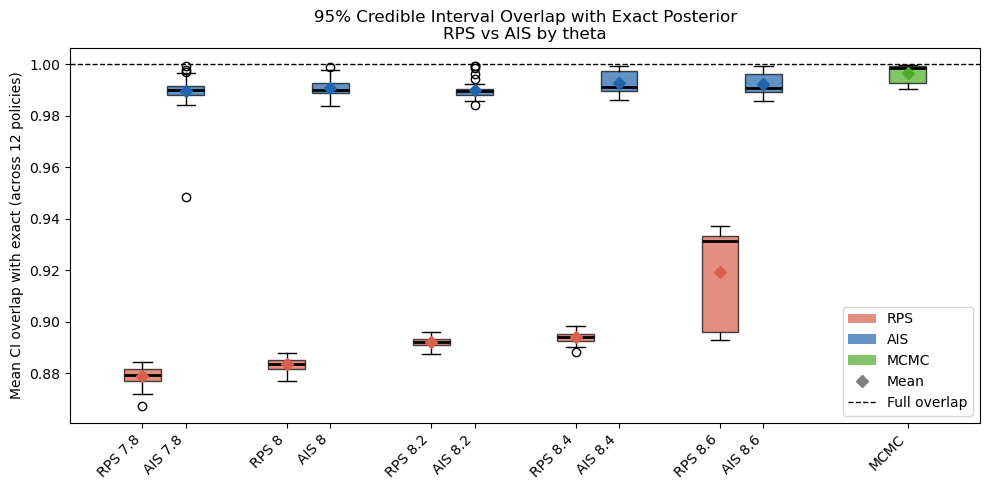

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

cols  = list(RPS_overlap.keys())   # theta labels only
x_pos = np.arange(len(cols))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 5))

bp1 = ax.boxplot([RPS_overlap[c] for c in cols], positions=x_pos - width, widths=width*0.85,
                 patch_artist=True, medianprops=dict(color='black', linewidth=2))
bp2 = ax.boxplot([AIS_overlap[c] for c in cols], positions=x_pos,          widths=width*0.85,
                 patch_artist=True, medianprops=dict(color='black', linewidth=2))
bp3 = ax.boxplot([MCMC_overlap],                 positions=[len(cols)],     widths=width*0.85,
                 patch_artist=True, medianprops=dict(color='black', linewidth=2))

for patch in bp1['boxes']:
    patch.set_facecolor('#d6604d'); patch.set_alpha(0.7)
for patch in bp2['boxes']:
    patch.set_facecolor('#2166ac'); patch.set_alpha(0.7)
for patch in bp3['boxes']:
    patch.set_facecolor('#4dac26'); patch.set_alpha(0.7)

ax.plot(x_pos - width, [np.mean(RPS_overlap[c]) for c in cols], 'D', color='#d6604d', markersize=6, zorder=5)
ax.plot(x_pos,         [np.mean(AIS_overlap[c]) for c in cols], 'D', color='#2166ac', markersize=6, zorder=5)
ax.plot([len(cols)],   [np.mean(MCMC_overlap)],                 'D', color='#4dac26', markersize=6, zorder=5)

all_ticks  = list(x_pos - width) + list(x_pos) + [len(cols)]
all_labels = [f'RPS {c}' for c in cols] + [f'AIS {c}' for c in cols] + ['MCMC']
ax.set_xticks(sorted(all_ticks))
ax.set_xticklabels([l for _, l in sorted(zip(all_ticks, all_labels))], rotation=45, ha='right')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Mean CI overlap with exact (across 12 policies)')
ax.set_title('95% Credible Interval Overlap with Exact Posterior\nRPS vs AIS by theta')

legend_elements = [
    mpatches.Patch(facecolor='#d6604d', alpha=0.7, label='RPS'),
    mpatches.Patch(facecolor='#2166ac', alpha=0.7, label='AIS'),
    mpatches.Patch(facecolor='#4dac26', alpha=0.7, label='MCMC'),
    plt.Line2D([0],[0], marker='D', color='gray', markersize=6, linestyle='None', label='Mean'),
    plt.Line2D([0],[0], color='black', linestyle='--', linewidth=1, label='Full overlap'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

In [86]:
import numpy as np

def hausdorff(lo_m, hi_m, lo_ref, hi_ref):
    """max(|lo_m - lo_ref|, |hi_m - hi_ref|) per policy."""
    return np.maximum(np.abs(lo_m - lo_ref), np.abs(hi_m - hi_ref))

def scaled_wasserstein(lo_m, hi_m, lo_ref, hi_ref):
    """((m-m*)/w*)^2 + ((w-w*)/w*)^2 per policy, scaled by reference half-width."""
    m     = (lo_m  + hi_m)  / 2;  w     = (hi_m  - lo_m)  / 2
    m_ref = (lo_ref + hi_ref) / 2; w_ref = (hi_ref - lo_ref) / 2
    loc   = ((m - m_ref) / w_ref) ** 2
    scale = ((w - w_ref) / w_ref) ** 2
    return loc + scale

thetas = [7.8,8,8.2,8.4,8.6]

HD_RPS   = {f"{t}": [] for t in thetas}
HD_AIS   = {f"{t}": [] for t in thetas}
HD_MCMC  = []
SW_RPS   = {f"{t}": [] for t in thetas}
SW_AIS   = {f"{t}": [] for t in thetas}
SW_MCMC  = []

for x in data:
    lo_ref = x['exact_quantiles']['0.025']
    hi_ref = x['exact_quantiles']['0.975']
    lo_mc  = x['MCMC_quantiles']['0.025']
    hi_mc  = x['MCMC_quantiles']['0.975']
    HD_MCMC.append(np.mean(hausdorff(lo_mc, hi_mc, lo_ref, hi_ref)))
    SW_MCMC.append(np.mean(scaled_wasserstein(lo_mc, hi_mc, lo_ref, hi_ref)))
    for theta in thetas:
        lo_r = x[f'RPS_{theta}_quantiles']['0.025']; hi_r = x[f'RPS_{theta}_quantiles']['0.975']
        lo_a = x[f'AIS_{theta}_quantiles']['0.025']; hi_a = x[f'AIS_{theta}_quantiles']['0.975']
        HD_RPS[f"{theta}"].append(np.mean(hausdorff(lo_r, hi_r, lo_ref, hi_ref)))
        HD_AIS[f"{theta}"].append(np.mean(hausdorff(lo_a, hi_a, lo_ref, hi_ref)))
        SW_RPS[f"{theta}"].append(np.mean(scaled_wasserstein(lo_r, hi_r, lo_ref, hi_ref)))
        SW_AIS[f"{theta}"].append(np.mean(scaled_wasserstein(lo_a, hi_a, lo_ref, hi_ref)))


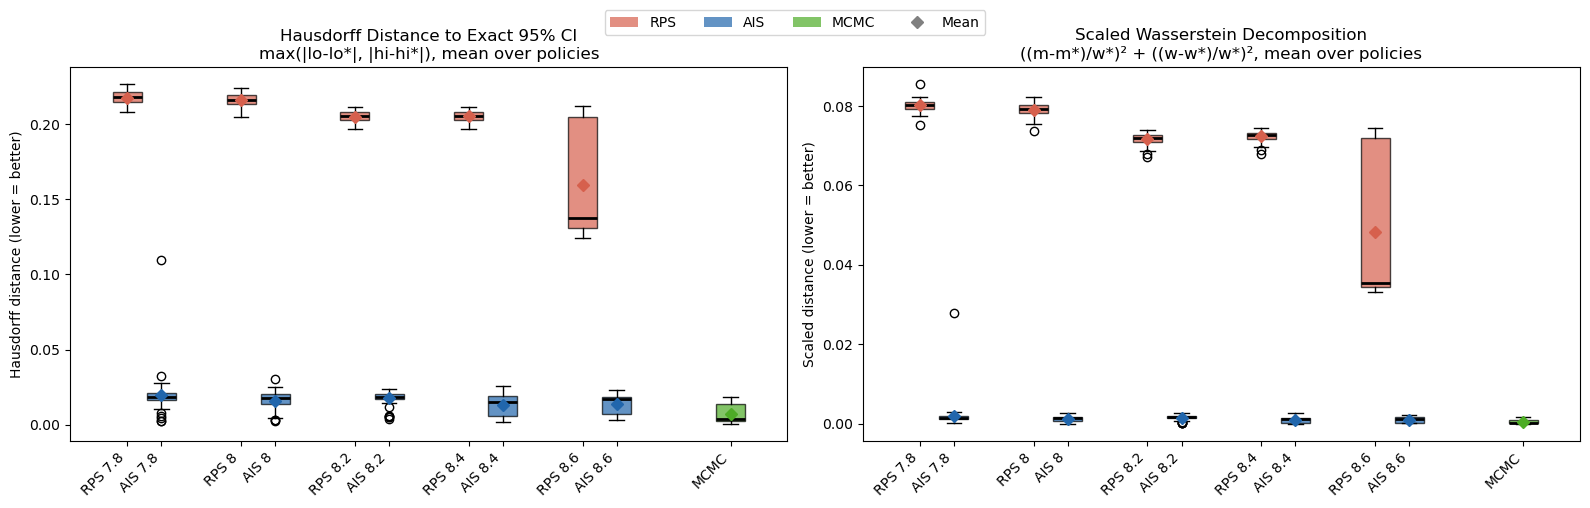

In [87]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def side_by_side_boxplot(ax, rps_dict, ais_dict, mcmc_list, title, ylabel):
    cols  = list(rps_dict.keys())
    x_pos = np.arange(len(cols))
    width = 0.3
    bp1 = ax.boxplot([rps_dict[c] for c in cols],  positions=x_pos - width, widths=width*0.85,
                     patch_artist=True, medianprops=dict(color='black', linewidth=2))
    bp2 = ax.boxplot([ais_dict[c] for c in cols],  positions=x_pos,         widths=width*0.85,
                     patch_artist=True, medianprops=dict(color='black', linewidth=2))
    bp3 = ax.boxplot([mcmc_list],                  positions=[len(cols)],   widths=width*0.85,
                     patch_artist=True, medianprops=dict(color='black', linewidth=2))
    for patch in bp1['boxes']: patch.set_facecolor('#d6604d'); patch.set_alpha(0.7)
    for patch in bp2['boxes']: patch.set_facecolor('#2166ac'); patch.set_alpha(0.7)
    for patch in bp3['boxes']: patch.set_facecolor('#4dac26'); patch.set_alpha(0.7)
    ax.plot(x_pos - width, [np.mean(rps_dict[c]) for c in cols], 'D', color='#d6604d', markersize=6, zorder=5)
    ax.plot(x_pos,         [np.mean(ais_dict[c]) for c in cols], 'D', color='#2166ac', markersize=6, zorder=5)
    ax.plot([len(cols)],   [np.mean(mcmc_list)],                 'D', color='#4dac26', markersize=6, zorder=5)
    all_ticks  = list(x_pos - width) + list(x_pos) + [len(cols)]
    all_labels = [f'RPS {c}' for c in cols] + [f'AIS {c}' for c in cols] + ['MCMC']
    ax.set_xticks(sorted(all_ticks))
    ax.set_xticklabels([l for _, l in sorted(zip(all_ticks, all_labels))], rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel(ylabel)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

side_by_side_boxplot(axes[0], HD_RPS, HD_AIS, HD_MCMC,
    'Hausdorff Distance to Exact 95% CI\nmax(|lo-lo*|, |hi-hi*|), mean over policies',
    'Hausdorff distance (lower = better)')

side_by_side_boxplot(axes[1], SW_RPS, SW_AIS, SW_MCMC,
    'Scaled Wasserstein Decomposition\n((m-m*)/w*)² + ((w-w*)/w*)², mean over policies',
    'Scaled distance (lower = better)')

legend_elements = [
    mpatches.Patch(facecolor='#d6604d', alpha=0.7, label='RPS'),
    mpatches.Patch(facecolor='#2166ac', alpha=0.7, label='AIS'),
    mpatches.Patch(facecolor='#4dac26', alpha=0.7, label='MCMC'),
    plt.Line2D([0],[0], marker='D', color='gray', markersize=6, linestyle='None', label='Mean'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()


Interval scoring rule

In [76]:
import numpy as np

# S_alpha(L, U; theta*) = (U-L) + (2/alpha)(L-theta*)1{theta*<L} + (2/alpha)(theta*-U)1{theta*>U}
def interval_score(L, U, theta_star, alpha=0.05):
    width     = U - L
    undershot = (2/alpha) * np.maximum(0, L - theta_star)
    overshot  = (2/alpha) * np.maximum(0, theta_star - U)
    return width + undershot + overshot

thetas = [7.8, 8, 8.2, 8.4, 8.6]
alpha  = 0.05   # 95% CI

# theta* = exact posterior mean per policy per replication
IS_RPS  = {f"{t}": [] for t in thetas}
IS_AIS  = {f"{t}": [] for t in thetas}
IS_MCMC = []

for x in data:
    theta_star = x['exact_quantiles']["0.5"]          # shape (n_policies,)
    mcmc_lo    = x['MCMC_quantiles']['0.025']
    mcmc_hi    = x['MCMC_quantiles']['0.975']
    IS_MCMC.append(np.sum(interval_score(mcmc_lo, mcmc_hi, theta_star, alpha)))
    for theta in thetas:
        rlo = x[f'RPS_{theta}_quantiles']['0.025']
        rhi = x[f'RPS_{theta}_quantiles']['0.975']
        alo = x[f'AIS_{theta}_quantiles']['0.025']
        ahi = x[f'AIS_{theta}_quantiles']['0.975']
        IS_RPS[f"{theta}"].append(np.sum(interval_score(rlo, rhi, theta_star, alpha)))
        IS_AIS[f"{theta}"].append(np.sum(interval_score(alo, ahi, theta_star, alpha)))


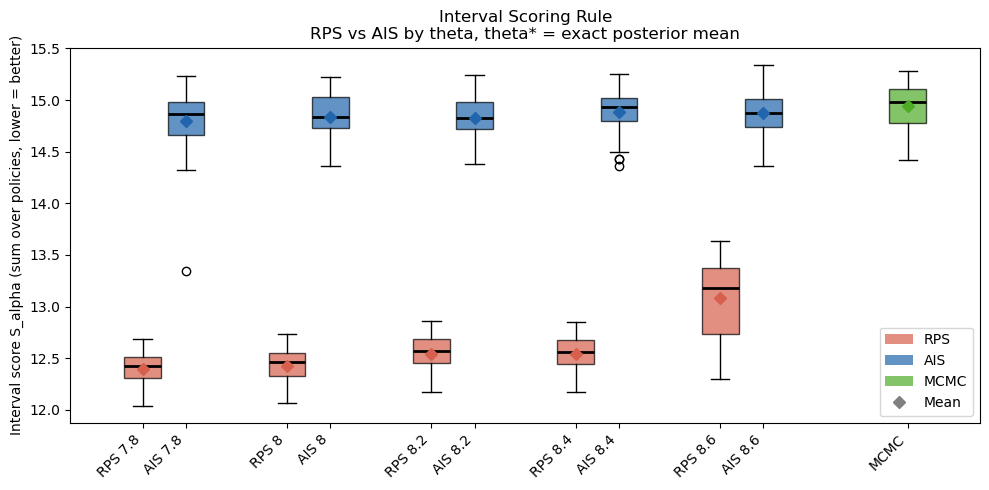

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

cols  = list(IS_RPS.keys())   # theta labels only, no MCMC
x_pos = np.arange(len(cols))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 5))

bp1 = ax.boxplot([IS_RPS[c] for c in cols], positions=x_pos - width, widths=width*0.85,
                 patch_artist=True, medianprops=dict(color='black', linewidth=2))
bp2 = ax.boxplot([IS_AIS[c] for c in cols], positions=x_pos,          widths=width*0.85,
                 patch_artist=True, medianprops=dict(color='black', linewidth=2))
bp3 = ax.boxplot([IS_MCMC],               positions=[len(cols)],      widths=width*0.85,
                 patch_artist=True, medianprops=dict(color='black', linewidth=2))

for patch in bp1['boxes']:
    patch.set_facecolor('#d6604d'); patch.set_alpha(0.7)
for patch in bp2['boxes']:
    patch.set_facecolor('#2166ac'); patch.set_alpha(0.7)
for patch in bp3['boxes']:
    patch.set_facecolor('#4dac26'); patch.set_alpha(0.7)

ax.plot(x_pos - width, [np.mean(IS_RPS[c]) for c in cols], 'D', color='#d6604d', markersize=6, zorder=5)
ax.plot(x_pos,         [np.mean(IS_AIS[c]) for c in cols], 'D', color='#2166ac', markersize=6, zorder=5)
ax.plot([len(cols)],   [np.mean(IS_MCMC)],                 'D', color='#4dac26', markersize=6, zorder=5)

all_ticks = list(x_pos - width) + list(x_pos) + [len(cols)]
all_labels = [f'RPS {c}' for c in cols] + [f'AIS {c}' for c in cols] + ['MCMC']
ax.set_xticks(sorted(all_ticks))
ax.set_xticklabels([l for _, l in sorted(zip(all_ticks, all_labels))], rotation=45, ha='right')
ax.set_ylabel(f'Interval score S_alpha (sum over policies, lower = better)')
ax.set_title('Interval Scoring Rule\nRPS vs AIS by theta, theta* = exact posterior mean')

legend_elements = [
    mpatches.Patch(facecolor='#d6604d', alpha=0.7, label='RPS'),
    mpatches.Patch(facecolor='#2166ac', alpha=0.7, label='AIS'),
    mpatches.Patch(facecolor='#4dac26', alpha=0.7, label='MCMC'),
    plt.Line2D([0],[0], marker='D', color='gray', markersize=6, linestyle='None', label='Mean'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()


In [69]:
exact_width=[]
MCMC_width=[]
RPS_8_width=[]
AIS_8_width=[]
for x in data:
    exact_width.append(np.mean(x["exact_quantiles"]["0.975"]-x["exact_quantiles"]["0.025"]))
    MCMC_width.append(np.mean(x["MCMC_quantiles"]["0.975"]-x["MCMC_quantiles"]["0.025"]))
    AIS_8_width.append(np.mean(x["AIS_8_quantiles"]["0.975"]-x["AIS_8_quantiles"]["0.025"]))
    RPS_8_width.append(np.mean(x["RPS_8_quantiles"]["0.975"]-x["RPS_8_quantiles"]["0.025"]))

{'whiskers': [<matplotlib.lines.Line2D at 0x150fa5d50>,
 'caps': [<matplotlib.lines.Line2D at 0x1510f5dd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x150fa6dd0>,
 'medians': [<matplotlib.lines.Line2D at 0x15109e190>,
 'fliers': [<matplotlib.lines.Line2D at 0x151da7150>,
 'means': []}

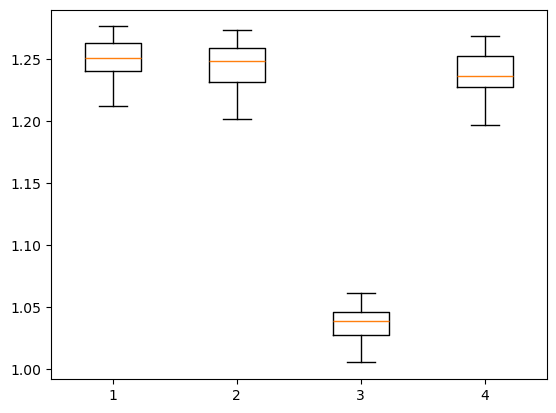

In [70]:
plt.boxplot(x=[exact_width,MCMC_width,RPS_8_width,AIS_8_width])

In [62]:
data[0]["RPS_8_quantiles"]["0.025"]

array([-0.07938018, -1.01684242, -0.99034923, -2.36827934, -0.09344553,
        0.74705697, -2.52900616, -0.10650948, -0.0925145 , -3.02364461,
       -0.11962633, -0.11127446])

In [63]:
data[0]["RPS_8_quantiles"]["0.975"]

array([ 0.09305617, -0.86934012, -0.84284693, -1.91557572,  2.5404655 ,
        2.5404655 , -1.95605082,  1.25331599,  1.68362523, -2.26848308,
        0.84312272,  1.68362523])

In [72]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC
lamb=1
theta=8.6
M = 2
R = np.array([4, 3])

num_profiles = 2**M
profiles, profile_map = hasse.enumerate_profiles(M)

all_policies = hasse.enumerate_policies(M, R)
num_policies = len(all_policies)

sigma_00 = None
mu_00 = np.array([0])
# mu_00 = np.array([5])
var_00 = np.array([1])

# Profile (0, 1)
sigma_01 = np.array([[1]])
mu_01 = np.array([-1])
# mu_01 = np.array([10])
var_01 = np.array([1])

# Profile (1, 0)
sigma_10 = np.array([[1, 0]])
mu_10 = np.array([-2, -3])
# mu_10 = np.array([-10, 15])
var_10 = np.array([1, 1])

# Profile (1, 1)
sigma_11 = np.array([[0, 1], [0, np.inf]])
mu_11 = np.array([2, 3, -1, 1])
# mu_11 = np.array([20, 30, 5, 10])
var_11 = np.array([1, 1, 1, 1])

sigma = [sigma_00, sigma_01, sigma_10, sigma_11]
mu = [mu_00, mu_01, mu_10, mu_11]
var = [var_00, var_01, var_10, var_11]

policies_profiles = {}
policies_profiles_masked = {}
policies_ids_profiles = {}
pi_policies = {}
pi_pools = {}
for k, profile in enumerate(profiles):

    policies_temp = [(i, x) for i, x in enumerate(all_policies) if hasse.policy_to_profile(x) == profile]
    unzipped_temp = list(zip(*policies_temp))
    policies_ids_k = list(unzipped_temp[0])
    policies_k = list(unzipped_temp[1])
    policies_profiles[k] = deepcopy(policies_k)
    policies_ids_profiles[k] = policies_ids_k

    profile_mask = list(map(bool, profile))

    # Mask the empty arms
    for idx, pol in enumerate(policies_k):
        policies_k[idx] = tuple([pol[i] for i in range(M) if profile_mask[i]])
    policies_profiles_masked[k] = policies_k

    if np.sum(profile) > 0:
        pi_pools_k, pi_policies_k = extract_pools.extract_pools(policies_k, sigma[k])
        if len(pi_pools_k.keys()) != mu[k].shape[0]:
            print(f"Profile {k}. Expected {len(pi_pools_k.keys())} pools. Received {mu[k].shape[0]} means.")
        pi_policies[k] = pi_policies_k
        # pi_pools_k has indicies that match with policies_profiles[k]
        # Need to map those indices back to all_policies
        pi_pools[k] = {}
        for x, y in pi_pools_k.items():
            y_full = [policies_profiles[k][i] for i in y]
            y_agg = [all_policies.index(i) for i in y_full]
            pi_pools[k][x] = y_agg
    else:
        pi_policies[k] = {0: 0}
        pi_pools[k] = {0: [0]}

def generate_data(mu, var, n_per_pol, all_policies, pi_policies, M):
    num_data = num_policies * n_per_pol
    X = np.zeros(shape=(num_data, M))
    D = np.zeros(shape=(num_data, 1), dtype='int_')
    y = np.zeros(shape=(num_data, 1))

    idx_ctr = 0
    for k, profile in enumerate(profiles):
        policies_k = policies_profiles[k]

        for idx, policy in enumerate(policies_k):
            policy_idx = [i for i, x in enumerate(all_policies) if x == policy]

            pool_id = pi_policies[k][idx]
            mu_i = mu[k][pool_id]
            var_i = var[k][pool_id]
            y_i = np.random.normal(mu_i, var_i, size=(n_per_pol, 1))

            start_idx = idx_ctr * n_per_pol
            end_idx = (idx_ctr + 1) * n_per_pol

            X[start_idx:end_idx, ] = policy
            D[start_idx:end_idx, ] = policy_idx[0]
            y[start_idx:end_idx, ] = y_i

            idx_ctr += 1

    return X, D, y

num_samples_per_feature = 500
length = []
X, D, y = generate_data(mu, var, num_samples_per_feature, all_policies, pi_policies, M)
policy_means = loss.compute_policy_means(D, y, num_policies)
prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)
# for iter in range(1,51):
#     np.random.seed(iter*42)
#     X, D, y = generate_data(mu, var, num_samples_per_feature, all_policies, pi_policies, M)
#     policy_means = loss.compute_policy_means(D, y, num_policies)
#     prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

#     def score_s(state):
#                 Q = AIS.global_loss_raw(
#                     state=state,
#                     D=D, y=y, M=M, R=R,
#                     prof_idx_of_policy = prof_idx_of_policy,
#                     policies=all_policies,
#                     policy_means=policy_means,
#                     reg=lamb, normalize=0,
#                     lattice_edges=None,
#                 )
#                 return float(np.exp(-Q))

#     H = np.inf
#     R_set, R_profiles = aggregate.RAggregate(M, R, H, D, y, theta, reg=lamb, verbose=True)

#     anchors = AIS.build_anchor_states(R_set, R_profiles, M, R)
#     prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

#     RPS_states = AIS.raggregate_to_states((R_set, R_profiles), profiles)
#     length.append(len(RPS_states))


In [110]:
np.min(length)

np.int64(27)

In [85]:
prob = [score_s(A) for A in RPS_states]

In [63]:
ais_out = AIS.run_ais_streaming_from_data(
                M, 
                R, 
                H, 
                D, 
                y, 
                theta, 
                reg=lamb,
                eps1=0.5,
                eps2=0.75,
                all_policies=all_policies,
                score_s=score_s,
                out_dir="./output_files",
                cfg = cfg,
            )

(0, 0) 7.713983213235162
Profile (0, 0) has 1 objects in Rashomon set
(0, 1) 7.787866083122113
Adaptive
Profile (0, 1) took 0.002752065658569336 s adaptively
Profile (0, 1) has 2 objects in Rashomon set
(1, 0) 7.861153034821504
Adaptive
Profile (1, 0) took 0.003144979476928711 s adaptively
Profile (1, 0) has 4 objects in Rashomon set
(1, 1) 8.129868070487802
Adaptive
Profile (1, 1) took 0.013110160827636719 s adaptively
Profile (1, 1) has 8 objects in Rashomon set
Finding feasible combinations
Min = 6.104129726871667, Max = 12.96904319944447
Running pilot adaptive ladder
Adaptive ladder has 6 levels; first 10: [0.   0.05 0.15 0.35 0.75 1.  ]
Per-step ESS ratios (len = 5 ): [1.0, 0.9913673317344911, 0.9661198469626824, 0.9435768657754946, 0.9865325923648947]


In [25]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import rashomon
importlib.reload(rashomon.MCMC)

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC
# mcmc_res = MCMC.load_mcmc_res_from_jsonl("./output_files/mcmc_samples1.jsonl")

# log_weight = np.log(np.repeat(1/len(mcmc_res["samples"]), len(mcmc_res["samples"])))

start = time.time()
mcmc_summ2 = MCMC.quantiles_for_all_policies(
    mcmc_res["samples"],
    log_weight,
    D, y,                     # D[:,0] = global policy id; y is (N,) or (N,1)
    M,
    all_policies,                 # global policies list (len P)
    prof_idx_of_policy,       # length-P array: global policy id -> profile k
    R,                    # per-arm levels (len M)
    lattice_edges=None,
    mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0,
    p=[0.025,0.5,0.975], 
    seed=None
)
end = time.time()
print(end-start)

# start = time.time()
# mcmc_summ = MCMC.quantiles_for_all_policies_root(
#     mcmc_res["samples"],
#     log_weight,
#     D, y,                     # D[:,0] = global policy id; y is (N,) or (N,1)
#     M,
#     all_policies,                 # global policies list (len P)
#     prof_idx_of_policy,       # length-P array: global policy id -> profile k
#     R,                    # per-arm levels (len M)
#     lattice_edges=None,
#     mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0,
#     p=[0.025,0.5,0.975], 
#     seed=None
# )
# end = time.time()
# print(end-start)

57.30595302581787


In [29]:
mcmc_summ["0.025"]-mcmc_summ2["0.025"]

array([-3.62102892e-09, -8.24176283e-10, -1.81870696e-09,  3.04001180e-09,
        4.06294443e-12, -1.86928351e-09,  3.21787041e-09, -2.16930185e-09,
        4.28895661e-09,  3.85105459e-09,  2.49540189e-09,  2.00185052e-09])

In [28]:
mcmc_summ["0.5"]-mcmc_summ2["0.5"]

array([ 4.04596083e-09, -3.75893872e-10,  5.80138881e-09, -2.29982122e-09,
       -2.61231126e-09,  4.26696523e-09, -5.99151395e-10, -3.08997317e-09,
       -2.32010733e-09, -2.38328246e-09, -6.07028178e-11,  4.07994383e-09])

In [31]:
for theta in [7.8, 8, 8.2, 8.4, 8.6]:
    H = np.inf
    R_set, R_profiles = aggregate.RAggregate(M, R, H, D, y, theta, reg=lamb, verbose=True)
    print(len(R_set))

(0, 0) 6.885645763374477
Profile (0, 0) has 1 objects in Rashomon set
(0, 1) 6.9520786022477195
Adaptive
Profile (0, 1) took 0.001474142074584961 s adaptively
Profile (0, 1) has 2 objects in Rashomon set
(1, 0) 7.0599964756153115
Adaptive
Profile (1, 0) took 0.0030837059020996094 s adaptively
Profile (1, 0) has 4 objects in Rashomon set
(1, 1) 7.280153286180922
Adaptive
Profile (1, 1) took 0.013002872467041016 s adaptively
Profile (1, 1) has 8 objects in Rashomon set
Finding feasible combinations
Min = 6.123715610025325, Max = 13.007375290860523
14
(0, 0) 7.085645763374477
Profile (0, 0) has 1 objects in Rashomon set
(0, 1) 7.15207860224772
Adaptive
Profile (0, 1) took 0.0016639232635498047 s adaptively
Profile (0, 1) has 2 objects in Rashomon set
(1, 0) 7.259996475615312
Adaptive
Profile (1, 0) took 0.0030999183654785156 s adaptively
Profile (1, 0) has 4 objects in Rashomon set
(1, 1) 7.480153286180922
Adaptive
Profile (1, 1) took 0.01302790641784668 s adaptively
Profile (1, 1) has 8 